# Avance Proyecto de Regresión: Magnitud de eventos sísmicos USGS 2024

Este notebook prepara el avance del proyecto de Análisis de Regresión usando el **USGS Earthquake Catalog**, catálogo oficial del **U.S. Geological Survey**. El periodo de estudio corresponde a eventos sísmicos registrados durante **2024** y el filtro de muestra es magnitud al menos 4.

- **Unidad de observación:** un evento sísmico registrado en el catálogo.
- **Variable respuesta:** magnitud del evento (`mag`).
- **Enfoque:** descriptivo-explicativo, centrado en asociaciones dentro de la muestra.
- **Pregunta de investigación:** ¿Cómo se asocia la magnitud de los eventos sísmicos registrados por USGS durante 2024 con su profundidad, localización geográfica y características técnicas del registro?

El objetivo no es predecir terremotos futuros ni construir un sistema operacional de alerta. El análisis busca describir asociaciones entre la magnitud reportada y variables observadas del catálogo, con herramientas de regresión lineal múltiple, inferencia y diagnóstico. Además, la muestra está truncada a eventos con `mag >= 4`; por lo tanto, las conclusiones no se extrapolan a sismos menores ni al proceso sísmico completo.


## 1. Librerías, rutas y configuración reproducible

Se usan librerías estándar para manipulación de datos, visualización y regresión lineal. Las rutas se construyen con `pathlib` para que el notebook funcione al ejecutarse desde la carpeta `Avance/` o desde la raíz del proyecto.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

def find_advance_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "Avance"] + [parent / "Avance" for parent in cwd.parents]
    for candidate in candidates:
        if (candidate / "usgs_earthquakes_2024_mag4_raw.csv").exists():
            return candidate
    raise FileNotFoundError("No se encontró usgs_earthquakes_2024_mag4_raw.csv en Avance/ ni en la carpeta actual.")

ADVANCE_DIR = find_advance_dir()
PROJECT_DIR = ADVANCE_DIR.parent
RAW_DATA_PATH = ADVANCE_DIR / "usgs_earthquakes_2024_mag4_raw.csv"
MODEL_READY_PATH = ADVANCE_DIR / "usgs_earthquakes_2024_mag4_model_ready.csv"
OUTPUT_DIR = ADVANCE_DIR / "outputs"
OUTPUT_FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = ADVANCE_DIR / "Plantilla_informe"
REPORT_FIG_DIR = REPORT_DIR / "figures"
REPORT_TABLE_DIR = REPORT_DIR / "tables"

for path in [OUTPUT_FIG_DIR, OUTPUT_TABLE_DIR, REPORT_FIG_DIR, REPORT_TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Carpeta Avance detectada: {ADVANCE_DIR.relative_to(PROJECT_DIR)}")
print(f"Archivo de datos: {RAW_DATA_PATH.relative_to(PROJECT_DIR)}")


Carpeta Avance detectada: Avance
Archivo de datos: Avance/usgs_earthquakes_2024_mag4_raw.csv


## 2. Carga de datos y revisión inicial

La base se lee directamente desde el archivo crudo. Primero se revisan dimensiones, nombres de columnas y tipos de datos. Si alguna columna esperada no está disponible, se reporta la ausencia y el resto del flujo continúa con las variables presentes.


In [2]:
df_raw = pd.read_csv(RAW_DATA_PATH)

required_columns = [
    "mag", "depth", "latitude", "longitude", "nst", "gap", "dmin", "rms",
    "magType", "net", "place", "time", "id"
]
missing_required = [col for col in required_columns if col not in df_raw.columns]
available_required = [col for col in required_columns if col in df_raw.columns]

print(f"Dimensiones de la base cruda: {df_raw.shape[0]:,} filas x {df_raw.shape[1]:,} columnas")
print("Columnas disponibles:")
print(list(df_raw.columns))
if missing_required:
    print("\nColumnas esperadas ausentes:", missing_required)
else:
    print("\nTodas las columnas principales esperadas están disponibles.")

print("\nTipos de datos originales:")
display(df_raw.dtypes.rename("tipo").to_frame())

print("\nPrimeras filas:")
display(df_raw.head())


Dimensiones de la base cruda: 14,176 filas x 22 columnas
Columnas disponibles:
['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']

Todas las columnas principales esperadas están disponibles.

Tipos de datos originales:


,tipo
time,object
latitude,float64
longitude,float64
depth,float64
mag,float64
magType,object
nst,float64
gap,float64
dmin,float64
rms,float64



Primeras filas:


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2024-01-01T00:37:09.096Z,17.6625,145.4596,384.941,4.7,mb,198.0,36.0,2.429,0.50,...,2024-03-09T21:38:09.040Z,"272 km N of Saipan, Northern Mariana Islands",earthquake,10.13,5.448,0.042,168.0,reviewed,us,us
1,2024-01-01T00:54:44.947Z,-57.3045,-25.8967,55.881,4.4,mb,18.0,107.0,6.694,0.54,...,2024-03-09T21:40:15.040Z,South Sandwich Islands region,earthquake,8.65,8.639,0.156,12.0,reviewed,us,us
2,2024-01-01T00:59:19.656Z,-6.8599,107.1224,178.051,4.1,mb,43.0,97.0,0.490,0.67,...,2024-03-09T21:38:11.040Z,"4 km SSW of Cianjur, Indonesia",earthquake,6.71,5.273,0.102,26.0,reviewed,us,us
3,2024-01-01T01:05:25.000Z,-25.3436,-70.5175,35.000,4.3,mb,19.0,178.0,0.804,0.62,...,2024-03-09T21:38:10.040Z,"7 km NNW of Taltal, Chile",earthquake,3.99,1.966,0.239,5.0,reviewed,us,us
4,2024-01-01T01:43:14.869Z,-24.4120,179.8704,513.317,4.6,mb,89.0,31.0,5.199,0.71,...,2024-03-09T21:38:11.040Z,south of the Fiji Islands,earthquake,10.66,0.841,0.044,154.0,reviewed,us,us


## 3. Conversión de tipos y creación de variables

Se convierte `time` a fecha-hora UTC y las variables numéricas relevantes se fuerzan a tipo numérico con `errors="coerce"`. También se crean variables temporales (`month`, `hour`, `weekday`), la transformación `log_depth_plus_1` y una región aproximada desde `place`. Para `region_from_place`, si el texto tiene coma se conserva lo que aparece después de la última coma; si no tiene coma, se marca como `Unknown/No comma`.


In [3]:
df = df_raw.copy()

numeric_columns = ["mag", "depth", "latitude", "longitude", "nst", "gap", "dmin", "rms"]
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)
    df["month"] = df["time"].dt.month
    df["hour"] = df["time"].dt.hour
    df["weekday"] = df["time"].dt.day_name()
else:
    df["month"] = np.nan
    df["hour"] = np.nan
    df["weekday"] = np.nan

if "depth" in df.columns:
    df["log_depth_plus_1"] = np.log1p(df["depth"].clip(lower=0))
else:
    df["log_depth_plus_1"] = np.nan

if "place" in df.columns:
    place = df["place"].astype("string")
    df["region_from_place"] = np.where(
        place.isna(),
        pd.NA,
        np.where(place.str.contains(",", regex=False, na=False), place.str.split(",").str[-1].str.strip(), "Unknown/No comma")
    )
    df["region_from_place"] = pd.Series(df["region_from_place"], index=df.index, dtype="string")
else:
    df["region_from_place"] = pd.Series(pd.NA, index=df.index, dtype="string")

created_columns = ["month", "hour", "weekday", "log_depth_plus_1", "region_from_place"]
print("Variables creadas:", created_columns)
display(df[available_required + [c for c in created_columns if c in df.columns]].head())


Variables creadas: ['month', 'hour', 'weekday', 'log_depth_plus_1', 'region_from_place']


,mag,depth,latitude,longitude,nst,gap,dmin,rms,magType,net,place,time,id,month,hour,weekday,log_depth_plus_1,region_from_place
0,4.7,384.941,17.6625,145.4596,198.0,36.0,2.429,0.50,mb,us,"272 km N of Saipan, Northern Mariana Islands",2024-01-01 00:37:09.096000+00:00,us6000m0w6,1,0,Monday,5.955685,Northern Mariana Islands
1,4.4,55.881,-57.3045,-25.8967,18.0,107.0,6.694,0.54,mb,us,South Sandwich Islands region,2024-01-01 00:54:44.947000+00:00,us6000m357,1,0,Monday,4.040961,Unknown/No comma
2,4.1,178.051,-6.8599,107.1224,43.0,97.0,0.490,0.67,mb,us,"4 km SSW of Cianjur, Indonesia",2024-01-01 00:59:19.656000+00:00,us6000m0wb,1,0,Monday,5.187671,Indonesia
3,4.3,35.000,-25.3436,-70.5175,19.0,178.0,0.804,0.62,mb,us,"7 km NNW of Taltal, Chile",2024-01-01 01:05:25+00:00,us6000m0wa,1,1,Monday,3.583519,Chile
4,4.6,513.317,-24.4120,179.8704,89.0,31.0,5.199,0.71,mb,us,south of the Fiji Islands,2024-01-01 01:43:14.869000+00:00,us6000m0wc,1,1,Monday,6.242840,Unknown/No comma


## 4. Diccionario de variables

La siguiente tabla resume el rol de las variables principales. La tabla se guarda en CSV y en formato LaTeX para el informe.


In [4]:
def latex_escape(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value)
    replacements = {
        "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$", "#": r"\#",
        "_": r"\_", "{": r"\{", "}": r"\}", "~": r"\textasciitilde{}", "^": r"\textasciicircum{}"
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text

def write_latex_tabular(df_table: pd.DataFrame, path: Path, column_format: str | None = None, index: bool = False):
    latex = df_table.to_latex(index=index, escape=True, column_format=column_format, bold_rows=False, float_format=lambda x: f"{x:.3f}")
    path.write_text(latex, encoding="utf-8")

def write_tabularx_two_col(rows, path: Path, first_col="Campo", second_col="Descripción"):
    row_end = r" \\"
    lines = [
        r"\begin{tabularx}{\textwidth}{@{}p{0.27\textwidth}X@{}}",
        r"\toprule",
        f"{latex_escape(first_col)} & {latex_escape(second_col)}{row_end}",
        r"\midrule",
    ]
    for left, right in rows:
        lines.append(f"{latex_escape(left)} & {latex_escape(right)}{row_end}")
    lines += [r"\bottomrule", r"\end{tabularx}"]
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

dictionary_rows = [
    ("mag", "Numérica continua", "Magnitud reportada del evento sísmico.", "Variable respuesta."),
    ("depth", "Numérica continua", "Profundidad del evento, usualmente en kilómetros según catálogo USGS.", "Predictor geofísico principal."),
    ("log_depth_plus_1", "Numérica transformada", "log(depth + 1), calculado como log1p(depth.clip(lower=0)).", "Transformación para reducir asimetría de profundidad."),
    ("latitude", "Numérica continua", "Latitud del epicentro.", "Localización geográfica."),
    ("longitude", "Numérica continua", "Longitud del epicentro.", "Localización geográfica."),
    ("nst", "Numérica discreta", "Número de estaciones usadas en la solución del evento.", "Característica técnica del registro."),
    ("gap", "Numérica continua", "Brecha azimutal de cobertura de estaciones.", "Característica técnica del registro."),
    ("dmin", "Numérica continua", "Distancia mínima a una estación reportante.", "Característica técnica del registro."),
    ("rms", "Numérica continua", "Error RMS del ajuste del evento.", "Característica técnica del registro."),
    ("month", "Numérica discreta", "Mes UTC del evento derivado desde time.", "Control temporal descriptivo."),
    ("hour", "Numérica discreta", "Hora UTC del evento derivada desde time.", "Control temporal descriptivo."),
    ("magType", "Categórica", "Tipo de magnitud reportada.", "Diferencias sistemáticas por escala de magnitud."),
    ("net", "Categórica", "Red u organismo que reporta el evento.", "Diferencias sistemáticas por red de reporte."),
    ("region_from_place", "Categórica derivada", "Región aproximada extraída desde el texto place.", "Resumen geográfico categórico."),
    ("place", "Texto", "Descripción textual del lugar del evento.", "Contexto y construcción de región."),
    ("time", "Fecha-hora", "Fecha y hora UTC del evento.", "Filtro temporal y variables derivadas."),
    ("id", "Identificador", "Identificador único del evento en el catálogo.", "Control de duplicados."),
]

dictionary_df = pd.DataFrame(dictionary_rows, columns=["variable", "tipo", "descripción", "uso en el análisis"])
dictionary_df.to_csv(REPORT_TABLE_DIR / "diccionario_variables.csv", index=False)
dictionary_df.to_csv(OUTPUT_TABLE_DIR / "diccionario_variables.csv", index=False)
write_latex_tabular(dictionary_df, REPORT_TABLE_DIR / "diccionario_variables.tex", column_format="llll")
display(dictionary_df)


,variable,tipo,descripción,uso en el análisis
0,mag,Numérica continua,Magnitud reportada del evento sísmico.,Variable respuesta.
1,depth,Numérica continua,"Profundidad del evento, usualmente en kilómetr...",Predictor geofísico principal.
2,log_depth_plus_1,Numérica transformada,"log(depth + 1), calculado como log1p(depth.cli...",Transformación para reducir asimetría de profu...
3,latitude,Numérica continua,Latitud del epicentro.,Localización geográfica.
4,longitude,Numérica continua,Longitud del epicentro.,Localización geográfica.
5,nst,Numérica discreta,Número de estaciones usadas en la solución del...,Característica técnica del registro.
6,gap,Numérica continua,Brecha azimutal de cobertura de estaciones.,Característica técnica del registro.
7,dmin,Numérica continua,Distancia mínima a una estación reportante.,Característica técnica del registro.
8,rms,Numérica continua,Error RMS del ajuste del evento.,Característica técnica del registro.
9,month,Numérica discreta,Mes UTC del evento derivado desde time.,Control temporal descriptivo.


## 5. Limpieza inicial y calidad de datos

La limpieza se limita a decisiones justificadas para el avance: mantener eventos con magnitud observada, del año 2024 y con `mag >= 4`. No se eliminan automáticamente valores atípicos de magnitud o profundidad; se identifican y se dejan para análisis de sensibilidad y diagnóstico. Para los modelos preliminares se usa eliminación por lista solo en las variables de cada fórmula.


In [5]:
relevant_columns = [
    "mag", "depth", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms",
    "magType", "net", "place", "region_from_place", "time", "month", "hour", "weekday", "id"
]
relevant_available = [col for col in relevant_columns if col in df.columns]

missing_summary = (
    pd.DataFrame({
        "variable": relevant_available,
        "n_missing": [df[col].isna().sum() for col in relevant_available],
        "pct_missing": [100 * df[col].isna().mean() for col in relevant_available],
        "tipo_dato": [str(df[col].dtype) for col in relevant_available],
        "n_unique": [df[col].nunique(dropna=True) for col in relevant_available],
    })
    .sort_values(["pct_missing", "variable"], ascending=[False, True])
    .reset_index(drop=True)
)
missing_summary["pct_missing"] = missing_summary["pct_missing"].round(2)
missing_summary.to_csv(REPORT_TABLE_DIR / "missing_summary.csv", index=False)
missing_summary.to_csv(OUTPUT_TABLE_DIR / "missing_summary.csv", index=False)
write_latex_tabular(missing_summary, REPORT_TABLE_DIR / "missing_summary.tex", column_format="lrrlr")
display(missing_summary)

if "id" in df.columns:
    duplicate_id_count = int(df["id"].duplicated(keep=False).sum())
    duplicate_unique_ids = int(df.loc[df["id"].duplicated(keep=False), "id"].nunique())
else:
    duplicate_id_count = 0
    duplicate_unique_ids = 0

print(f"Registros involucrados en duplicados por id: {duplicate_id_count}")
print(f"IDs duplicados distintos: {duplicate_unique_ids}")


,variable,n_missing,pct_missing,tipo_dato,n_unique
0,dmin,52,0.37,float64,6546
1,gap,52,0.37,float64,279
2,nst,51,0.36,float64,299
3,rms,1,0.01,float64,150
4,depth,0,0.00,float64,8359
5,hour,0,0.00,int32,24
6,id,0,0.00,object,14176
7,latitude,0,0.00,float64,14042
8,log_depth_plus_1,0,0.00,float64,8359
9,longitude,0,0.00,float64,14035


Registros involucrados en duplicados por id: 0
IDs duplicados distintos: 0


In [6]:
range_checks = []

def add_check(name, condition, description):
    if condition is None:
        count = np.nan
    else:
        count = int(condition.sum())
    range_checks.append({"revisión": name, "n_casos": count, "comentario": description})

add_check("mag < 4", df["mag"] < 4 if "mag" in df.columns else None, "La muestra del proyecto debiera estar truncada en magnitud >= 4.")
add_check("latitude fuera de [-90, 90]", ~df["latitude"].between(-90, 90) if "latitude" in df.columns else None, "Latitudes fuera de rango geográfico plausible.")
add_check("longitude fuera de [-180, 180]", ~df["longitude"].between(-180, 180) if "longitude" in df.columns else None, "Longitudes fuera del rango geográfico usual.")
add_check("depth < 0", df["depth"] < 0 if "depth" in df.columns else None, "Profundidades levemente negativas pueden aparecer por incertidumbre de estimación; se reportan, no se eliminan automáticamente.")
add_check("gap fuera de [0, 360]", ~df["gap"].between(0, 360) if "gap" in df.columns else None, "La brecha azimutal debería estar entre 0 y 360 grados si está disponible.")
add_check("rms < 0", df["rms"] < 0 if "rms" in df.columns else None, "El RMS debería ser no negativo si está disponible.")

range_checks_df = pd.DataFrame(range_checks)
range_checks_df.to_csv(OUTPUT_TABLE_DIR / "range_checks.csv", index=False)
write_latex_tabular(range_checks_df, OUTPUT_TABLE_DIR / "range_checks.tex", column_format="lrl")
display(range_checks_df)

mask = pd.Series(True, index=df.index)
if "mag" in df.columns:
    mask &= df["mag"].notna() & (df["mag"] >= 4)
if "time" in df.columns:
    mask &= df["time"].dt.year.eq(2024)

df_model = df.loc[mask].copy()
if "id" in df_model.columns:
    before = len(df_model)
    df_model = df_model.drop_duplicates(subset="id", keep="first").copy()
    print(f"Duplicados por id removidos para base procesada: {before - len(df_model)}")

print(f"Filas en base procesada: {len(df_model):,}")
df_model.to_csv(MODEL_READY_PATH, index=False)
print(f"Base procesada guardada en: {MODEL_READY_PATH.relative_to(PROJECT_DIR)}")


def observed_range_text(data: pd.DataFrame, column: str, digits: int = 3) -> str:
    if column not in data.columns or data[column].dropna().empty:
        return "No disponible"
    min_value = data[column].min()
    max_value = data[column].max()
    return f"{min_value:.{digits}f} a {max_value:.{digits}f}"

missing_focus = [col for col in ["dmin", "gap", "nst", "rms"] if col in df_model.columns]
missing_focus_text = "; ".join(
    f"{col}: {int(df_model[col].isna().sum())} ({100 * df_model[col].isna().mean():.2f}%)"
    for col in missing_focus
)
if not missing_focus_text:
    missing_focus_text = "No disponible para las variables técnicas esperadas."

negative_depth_count = int((df_model["depth"] < 0).sum()) if "depth" in df_model.columns else 0
negative_depth_text = (
    "No se observan profundidades negativas."
    if negative_depth_count == 0
    else f"{negative_depth_count} evento" + ("" if negative_depth_count == 1 else "s") + "; se reporta y no se elimina automáticamente."
)
cleaning_summary = pd.DataFrame([
    {"revisión": "Duplicados por id", "resultado": f"{duplicate_id_count} registros involucrados ({duplicate_unique_ids} ids duplicados)."},
    {"revisión": "Rango observado de mag", "resultado": observed_range_text(df_model, "mag", 1)},
    {"revisión": "Rango observado de depth", "resultado": observed_range_text(df_model, "depth", 3)},
    {"revisión": "Rango observado de latitude", "resultado": observed_range_text(df_model, "latitude", 3)},
    {"revisión": "Rango observado de longitude", "resultado": observed_range_text(df_model, "longitude", 3)},
    {"revisión": "Profundidades negativas", "resultado": negative_depth_text},
    {"revisión": "Faltantes principales", "resultado": missing_focus_text},
])
cleaning_summary.to_csv(REPORT_TABLE_DIR / "cleaning_summary.csv", index=False)
cleaning_summary.to_csv(OUTPUT_TABLE_DIR / "cleaning_summary.csv", index=False)
write_latex_tabular(cleaning_summary, REPORT_TABLE_DIR / "cleaning_summary.tex", column_format="ll")
display(cleaning_summary)



,revisión,n_casos,comentario
0,mag < 4,0,La muestra del proyecto debiera estar truncada...
1,"latitude fuera de [-90, 90]",0,Latitudes fuera de rango geográfico plausible.
2,"longitude fuera de [-180, 180]",0,Longitudes fuera del rango geográfico usual.
3,depth < 0,1,Profundidades levemente negativas pueden apare...
4,"gap fuera de [0, 360]",52,La brecha azimutal debería estar entre 0 y 360...
5,rms < 0,0,El RMS debería ser no negativo si está disponi...


Duplicados por id removidos para base procesada: 0
Filas en base procesada: 14,176


Base procesada guardada en: Avance/usgs_earthquakes_2024_mag4_model_ready.csv


,revisión,resultado
0,Duplicados por id,0 registros involucrados (0 ids duplicados).
1,Rango observado de mag,4.0 a 7.5
2,Rango observado de depth,-0.070 a 671.043
3,Rango observado de latitude,-65.301 a 86.605
4,Rango observado de longitude,-179.999 a 179.998
5,Profundidades negativas,1 evento; se reporta y no se elimina automátic...
6,Faltantes principales,dmin: 52 (0.37%); gap: 52 (0.37%); nst: 51 (0....


## 6. Ficha inicial del conjunto de datos

La ficha resume fuente, unidad de observación, variables candidatas y dificultades esperadas. Esta información conecta los datos con la pregunta de investigación y explicita limitaciones antes de ajustar modelos.


In [7]:
main_missing = (
    missing_summary.loc[missing_summary["n_missing"] > 0, ["variable", "pct_missing"]]
    .head(5)
    .assign(texto=lambda x: x["variable"] + " (" + x["pct_missing"].astype(str) + "%)")
)
missing_text = "; ".join(main_missing["texto"].tolist()) if len(main_missing) else "No se observan faltantes en las variables principales revisadas."

ficha_rows = [
    ("Fuente", "U.S. Geological Survey, Earthquake Catalog API."),
    ("Contexto", "Eventos sísmicos registrados durante 2024 con magnitud al menos 4."),
    ("Unidad de observación", "Evento sísmico registrado en el catálogo."),
    ("Variable dependiente numérica", "Magnitud del evento (mag)."),
    ("Predictores candidatos", "depth, latitude, longitude, nst, gap, dmin, rms, magType, net, month, hour y region_from_place."),
    ("Tamaño muestral", f"{len(df_model):,} eventos después de la limpieza inicial."),
    ("Datos faltantes", missing_text),
    ("Dificultades del análisis", "Truncamiento por mag >= 4; asimetría o concentración de magnitudes; valores atípicos; faltantes en variables técnicas; posible colinealidad; dependencia espacial; categóricas con muchas categorías; variables técnicas no necesariamente causales."),
]
ficha_df = pd.DataFrame(ficha_rows, columns=["campo", "descripción"])
write_tabularx_two_col(ficha_rows, REPORT_TABLE_DIR / "ficha_datos.tex", first_col="Campo", second_col="Descripción")
ficha_df.to_csv(OUTPUT_TABLE_DIR / "ficha_datos.csv", index=False)
display(ficha_df)


,campo,descripción
0,Fuente,"U.S. Geological Survey, Earthquake Catalog API."
1,Contexto,Eventos sísmicos registrados durante 2024 con ...
2,Unidad de observación,Evento sísmico registrado en el catálogo.
3,Variable dependiente numérica,Magnitud del evento (mag).
4,Predictores candidatos,"depth, latitude, longitude, nst, gap, dmin, rm..."
5,Tamaño muestral,"14,176 eventos después de la limpieza inicial."
6,Datos faltantes,dmin (0.37%); gap (0.37%); nst (0.36%); rms (0...
7,Dificultades del análisis,Truncamiento por mag >= 4; asimetría o concent...


## 7. Variables categóricas agrupadas

`magType`, `net` y `region_from_place` pueden tener muchas categorías, algunas con muy pocas observaciones. Para evitar modelos con demasiadas variables indicadoras inestables, se conservan niveles frecuentes y se agrupa el resto como `Other`. Esta decisión mejora la estabilidad de los modelos lineales sin eliminar observaciones.


In [8]:
def group_categories(series: pd.Series, min_count: int = 30, top_n: int = 8, other_label: str = "Other") -> pd.Series:
    s = series.astype("string").fillna("Missing")
    counts = s.value_counts(dropna=False)
    keep_by_count = set(counts[counts >= min_count].index.tolist())
    keep_top = set(counts.head(top_n).index.tolist())
    keep = keep_by_count.union(keep_top)
    return s.where(s.isin(keep), other_label).astype("category")

categorical_specs = {
    "magType": "magType_grouped",
    "net": "net_grouped",
    "region_from_place": "region_grouped",
}
frequency_tables = {}
for original, grouped in categorical_specs.items():
    if original in df_model.columns:
        df_model[grouped] = group_categories(df_model[original], min_count=30, top_n=8)
        before_freq = df_model[original].astype("string").fillna("Missing").value_counts().rename_axis(original).reset_index(name="n")
        after_freq = df_model[grouped].astype("string").value_counts().rename_axis(grouped).reset_index(name="n")
        frequency_tables[f"{original}_before"] = before_freq
        frequency_tables[f"{grouped}_after"] = after_freq
        before_freq.to_csv(OUTPUT_TABLE_DIR / f"freq_{original}_before.csv", index=False)
        after_freq.to_csv(OUTPUT_TABLE_DIR / f"freq_{grouped}_after.csv", index=False)
        print(f"\n{original}: niveles antes = {before_freq.shape[0]}, después = {after_freq.shape[0]}")
        display(after_freq)
    else:
        df_model[grouped] = "Missing"

df_model.to_csv(MODEL_READY_PATH, index=False)



magType: niveles antes = 8, después = 8


,magType_grouped,n
0,mb,12215
1,mww,1172
2,mwr,623
3,ml,65
4,mw,58
5,md,38
6,mwb,4
7,mh,1



net: niveles antes = 11, después = 9


,net_grouped,n
0,us,13981
1,ak,51
2,pr,44
3,nc,32
4,ci,30
5,hv,13
6,tx,13
7,Other,6
8,nn,6



region_from_place: niveles antes = 149, después = 46


,region_grouped,n
0,Unknown/No comma,2802
1,Indonesia,1387
2,Japan,856
3,Philippines,771
4,Papua New Guinea,609
5,Other,607
6,Tonga,602
7,Chile,537
8,Taiwan,429
9,Vanuatu,425


## 8. Análisis exploratorio ligado a la pregunta

Los gráficos siguientes no buscan catalogar todas las variables, sino revisar relaciones directamente conectadas con la pregunta: distribución de la magnitud, asociación con profundidad y variables técnicas, diferencias por tipo de magnitud, y patrón geográfico.


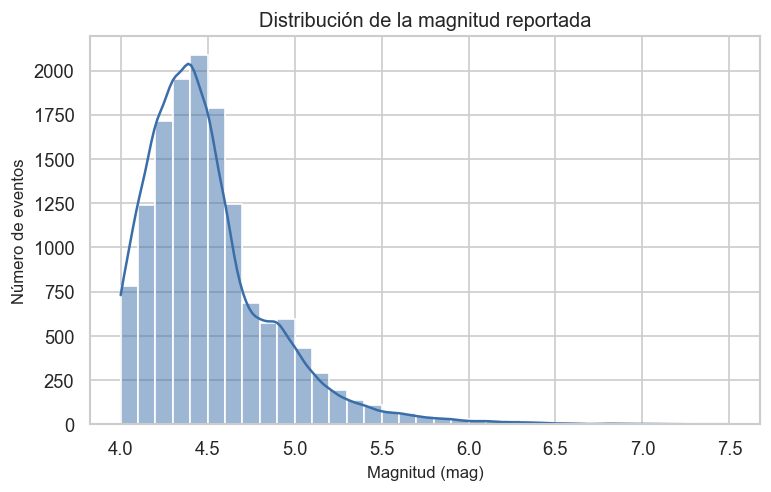

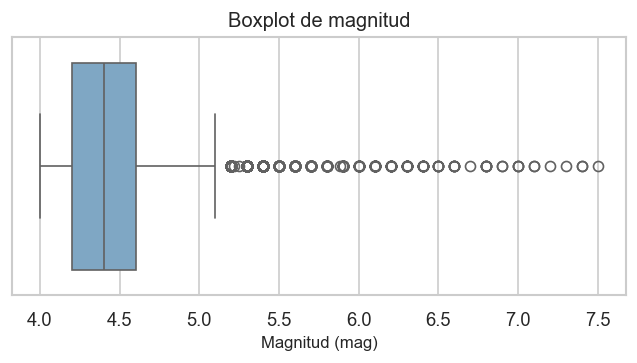

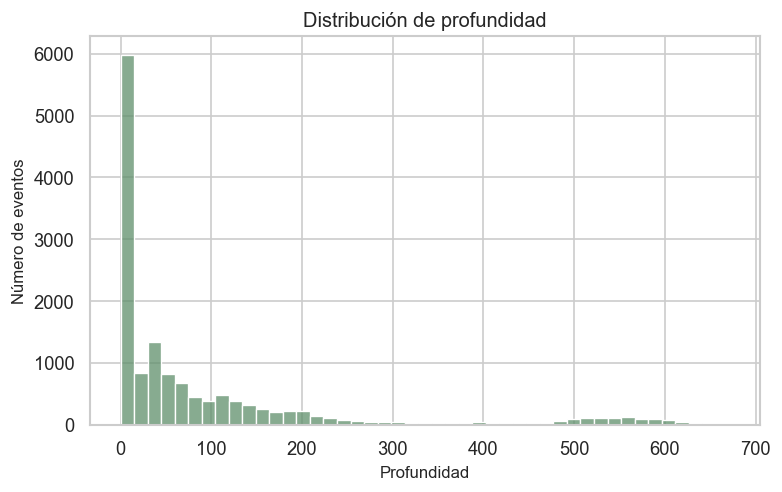

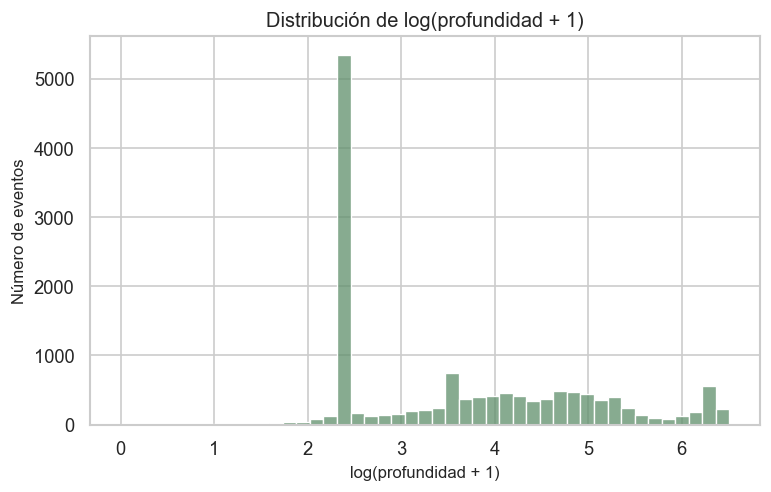

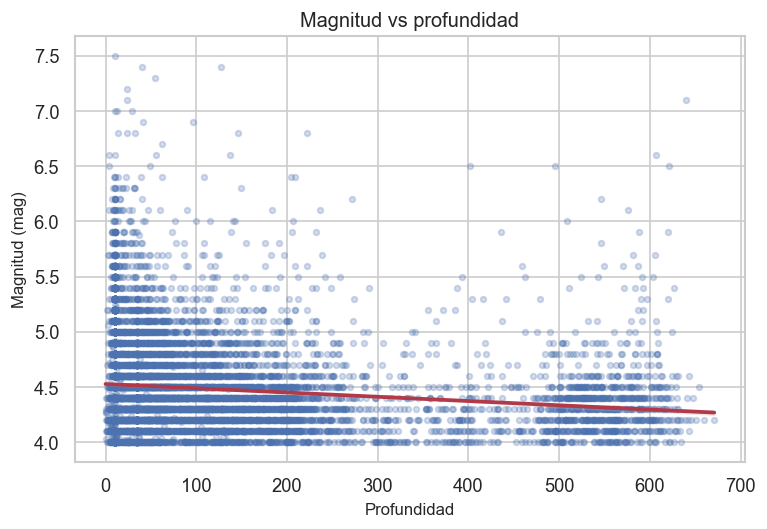

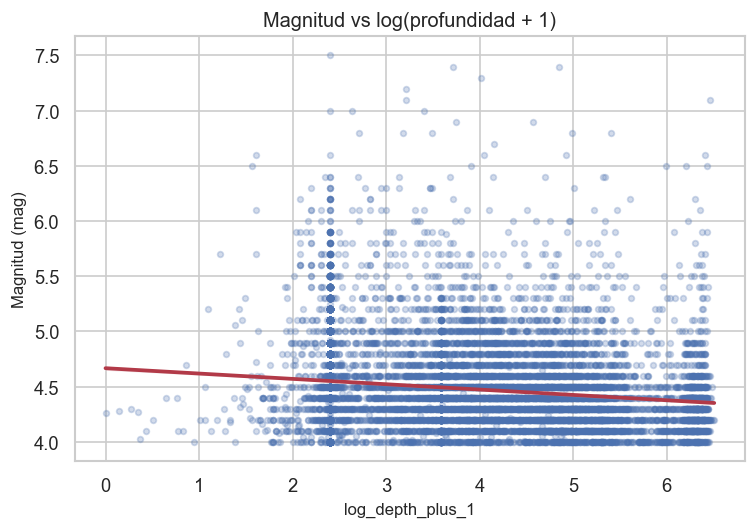

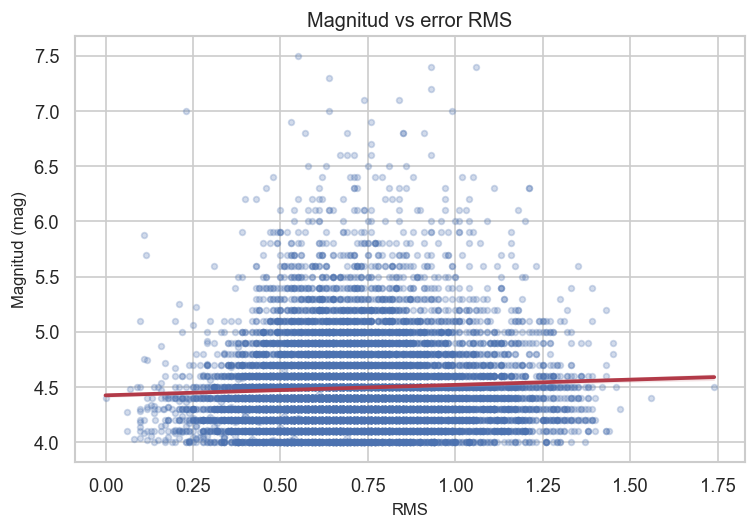

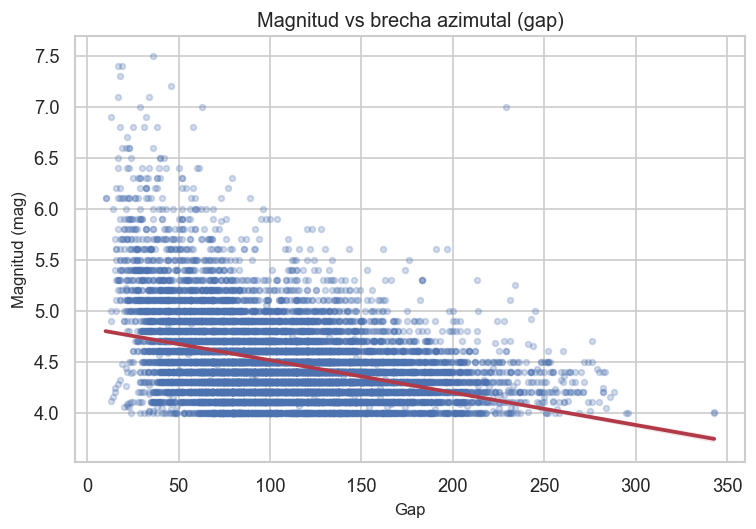

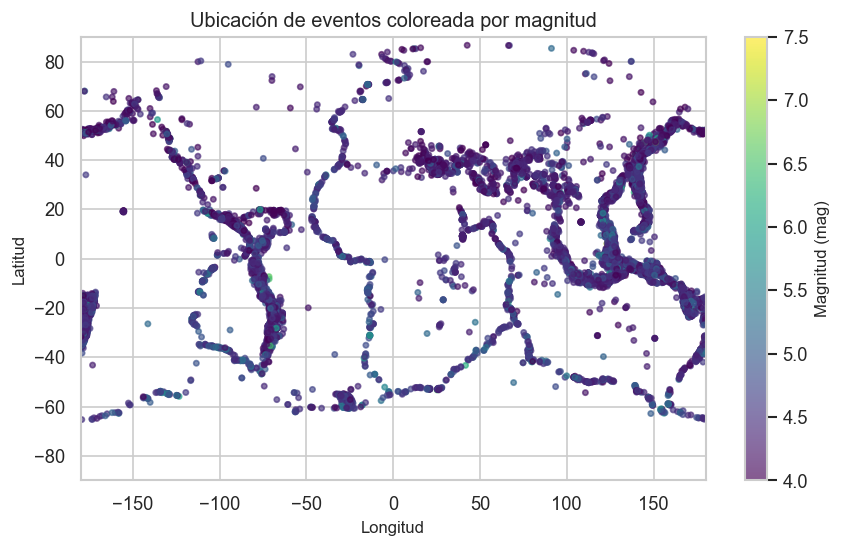

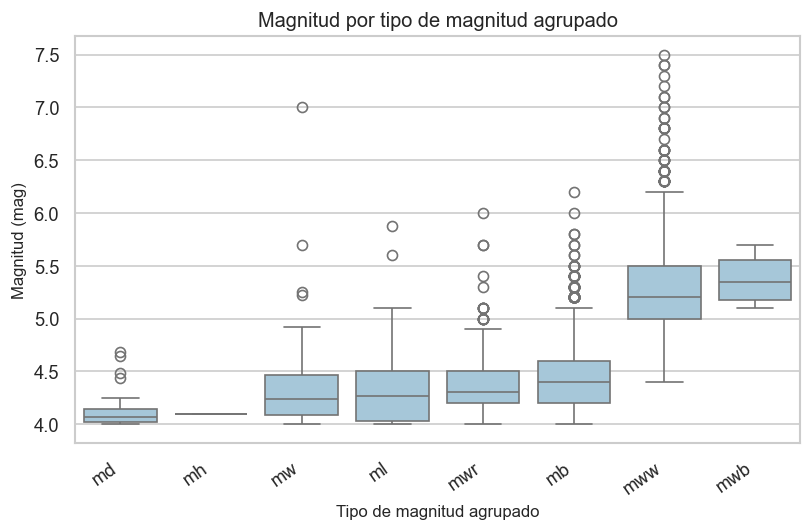

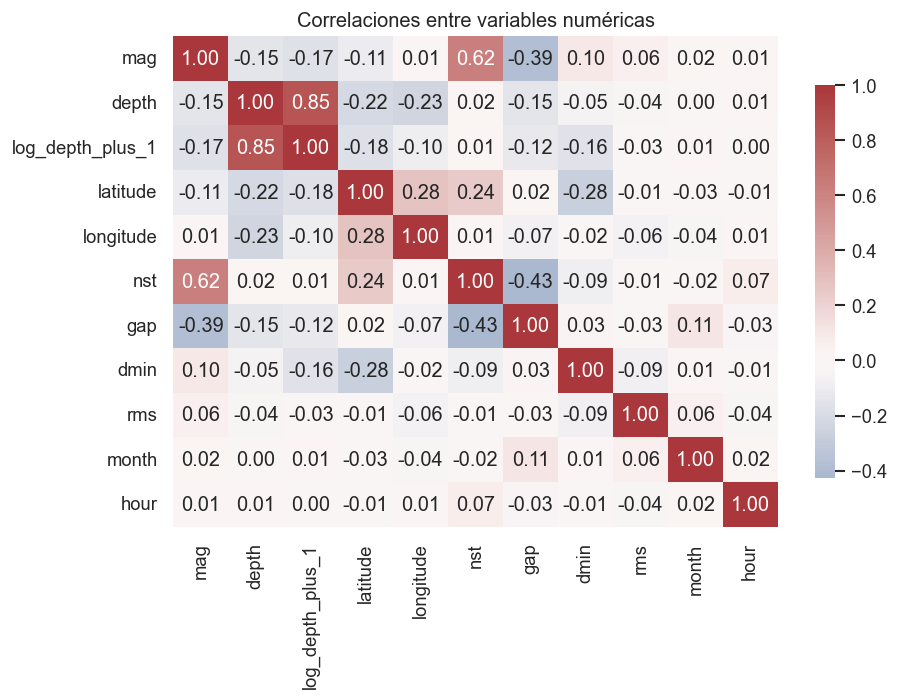

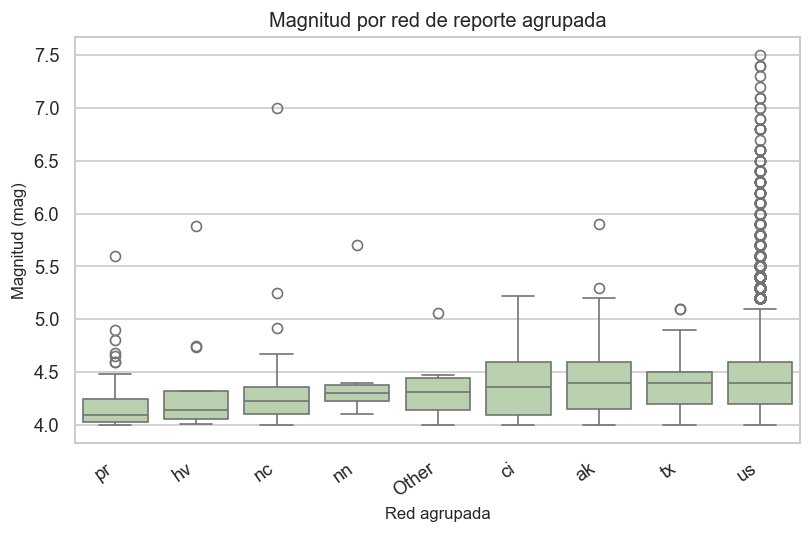

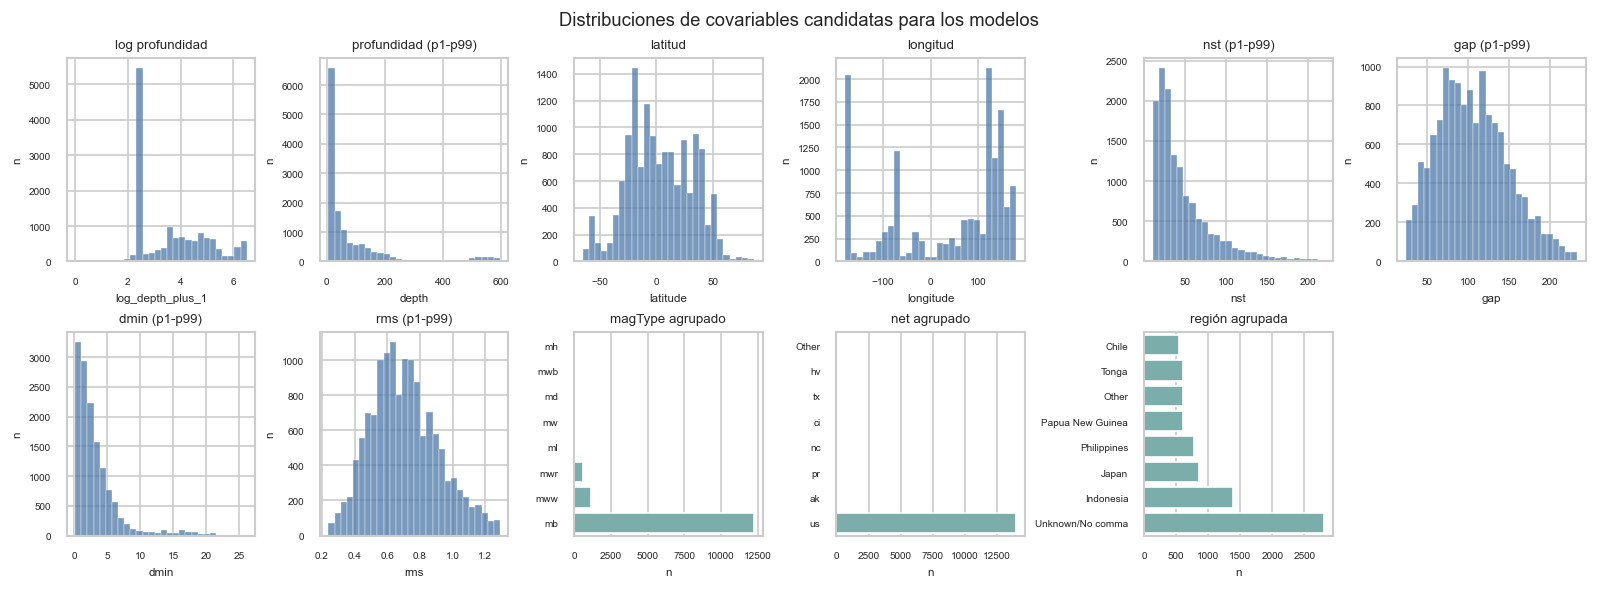

In [9]:
def save_current_figure(name: str):
    for directory in [REPORT_FIG_DIR, OUTPUT_FIG_DIR]:
        plt.savefig(directory / f"{name}.png", bbox_inches="tight")
        plt.savefig(directory / f"{name}.pdf", bbox_inches="tight")
    plt.show()

# 1. Distribución de magnitud
plt.figure(figsize=(7.2, 4.2))
sns.histplot(data=df_model, x="mag", bins=35, kde=True, color="#3b6ea8")
plt.title("Distribución de la magnitud reportada")
plt.xlabel("Magnitud (mag)")
plt.ylabel("Número de eventos")
save_current_figure("fig_hist_mag")

# 2. Boxplot de magnitud
plt.figure(figsize=(6.6, 2.8))
sns.boxplot(data=df_model, x="mag", color="#74a9cf")
plt.title("Boxplot de magnitud")
plt.xlabel("Magnitud (mag)")
save_current_figure("fig_box_mag")

# 3. Distribución de profundidad
if "depth" in df_model.columns:
    plt.figure(figsize=(7.2, 4.2))
    sns.histplot(data=df_model, x="depth", bins=45, kde=False, color="#5f8f6b")
    plt.title("Distribución de profundidad")
    plt.xlabel("Profundidad")
    plt.ylabel("Número de eventos")
    save_current_figure("fig_hist_depth")

#3.1 Distribución de log(profundidad + 1)
if "log_depth_plus_1" in df_model.columns:
    plt.figure(figsize=(7.2, 4.2))
    sns.histplot(data=df_model, x="log_depth_plus_1", bins=45, kde=False, color="#5f8f6b")
    plt.title("Distribución de log(profundidad + 1)")
    plt.xlabel("log(profundidad + 1)")
    plt.ylabel("Número de eventos")
    save_current_figure("fig_hist_log_depth")

# 4. Magnitud vs profundidad
if {"mag", "depth"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "depth"]].dropna()
    plt.figure(figsize=(7.2, 4.6))
    sns.regplot(data=plot_df, x="depth", y="mag", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "#b23a48"})
    plt.title("Magnitud vs profundidad")
    plt.xlabel("Profundidad")
    plt.ylabel("Magnitud (mag)")
    save_current_figure("fig_scatter_mag_depth")

# 5. Magnitud vs log profundidad
if {"mag", "log_depth_plus_1"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "log_depth_plus_1"]].dropna()
    plt.figure(figsize=(7.2, 4.6))
    sns.regplot(data=plot_df, x="log_depth_plus_1", y="mag", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "#b23a48"})
    plt.title("Magnitud vs log(profundidad + 1)")
    plt.xlabel("log_depth_plus_1")
    plt.ylabel("Magnitud (mag)")
    save_current_figure("fig_scatter_mag_logdepth")

# 6. Magnitud vs RMS
if {"mag", "rms"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "rms"]].dropna()
    plt.figure(figsize=(7.2, 4.6))
    sns.regplot(data=plot_df, x="rms", y="mag", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "#b23a48"})
    plt.title("Magnitud vs error RMS")
    plt.xlabel("RMS")
    plt.ylabel("Magnitud (mag)")
    save_current_figure("fig_scatter_mag_rms")

# 7. Magnitud vs gap
if {"mag", "gap"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "gap"]].dropna()
    plt.figure(figsize=(7.2, 4.6))
    sns.regplot(data=plot_df, x="gap", y="mag", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "#b23a48"})
    plt.title("Magnitud vs brecha azimutal (gap)")
    plt.xlabel("Gap")
    plt.ylabel("Magnitud (mag)")
    save_current_figure("fig_scatter_mag_gap")


# 8. Mapa simple
if {"longitude", "latitude", "mag"}.issubset(df_model.columns):
    plot_df = df_model[["longitude", "latitude", "mag"]].dropna()
    plt.figure(figsize=(8.4, 4.8))
    scatter = plt.scatter(plot_df["longitude"], plot_df["latitude"], c=plot_df["mag"], s=10, alpha=0.65, cmap="viridis")
    plt.colorbar(scatter, label="Magnitud (mag)")
    plt.title("Ubicación de eventos coloreada por magnitud")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    save_current_figure("fig_map_mag")

# 9. Boxplot de magnitud por tipo de magnitud agrupado
if {"mag", "magType_grouped"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "magType_grouped"]].dropna().copy()
    order = plot_df.groupby("magType_grouped", observed=True)["mag"].median().sort_values().index
    plt.figure(figsize=(7.8, 4.4))
    sns.boxplot(data=plot_df, x="magType_grouped", y="mag", order=order, color="#9ecae1")
    plt.title("Magnitud por tipo de magnitud agrupado")
    plt.xlabel("Tipo de magnitud agrupado")
    plt.ylabel("Magnitud (mag)")
    plt.xticks(rotation=35, ha="right")
    save_current_figure("fig_box_mag_magtype")

# 10. Matriz de correlaciones numéricas
corr_vars = ["mag", "depth", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms", "month", "hour"]
corr_vars = [col for col in corr_vars if col in df_model.columns]
if len(corr_vars) >= 2:
    corr = df_model[corr_vars].corr(numeric_only=True)
    plt.figure(figsize=(8.0, 6.0))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=False, cbar_kws={"shrink": 0.8})
    plt.title("Correlaciones entre variables numéricas")
    plt.tight_layout()
    save_current_figure("fig_corr_numeric")

# 11. Magnitud por red de reporte agrupada
if {"mag", "net_grouped"}.issubset(df_model.columns):
    plot_df = df_model[["mag", "net_grouped"]].dropna().copy()
    order = plot_df.groupby("net_grouped", observed=True)["mag"].median().sort_values().index
    plt.figure(figsize=(7.8, 4.4))
    sns.boxplot(data=plot_df, x="net_grouped", y="mag", order=order, color="#b7d7a8")
    plt.title("Magnitud por red de reporte agrupada")
    plt.xlabel("Red agrupada")
    plt.ylabel("Magnitud (mag)")
    plt.xticks(rotation=35, ha="right")
    save_current_figure("fig_box_mag_net")

# 12. Distribuciones de covariables usadas en los modelos
# Esta figura resume tipos de dato: histogramas para numéricas y barras para categóricas agrupadas.
distribution_panels = [
    ("log_depth_plus_1", "numeric", "log profundidad"),
    ("depth", "numeric_trim", "profundidad (p1-p99)"),
    ("latitude", "numeric", "latitud"),
    ("longitude", "numeric", "longitud"),
    ("nst", "numeric_trim", "nst (p1-p99)"),
    ("gap", "numeric_trim", "gap (p1-p99)"),
    ("dmin", "numeric_trim", "dmin (p1-p99)"),
    ("rms", "numeric_trim", "rms (p1-p99)"),
    ("magType_grouped", "categorical", "magType agrupado"),
    ("net_grouped", "categorical", "net agrupado"),
    ("region_grouped", "categorical", "región agrupada"),
]

fig, axes = plt.subplots(2, 6, figsize=(13.2, 4.8), constrained_layout=True)
axes = axes.ravel()
for ax, (var, kind, title) in zip(axes, distribution_panels):
    if var not in df_model.columns:
        ax.axis("off")
        ax.set_title(f"{title}\n(no disponible)", fontsize=9)
        continue
    if kind.startswith("numeric"):
        values = pd.to_numeric(df_model[var], errors="coerce").dropna()
        if kind == "numeric_trim" and len(values) > 0:
            q_low, q_high = values.quantile([0.01, 0.99])
            if np.isfinite(q_low) and np.isfinite(q_high) and q_high > q_low:
                values = values[(values >= q_low) & (values <= q_high)]
        sns.histplot(values, bins=28, ax=ax, color="#4C78A8", edgecolor="white", linewidth=0.2)
        ax.set_xlabel(var, fontsize=7)
        ax.set_ylabel("n", fontsize=7)
    else:
        counts = df_model[var].astype("string").fillna("Missing").value_counts().head(8).sort_values()
        sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#72B7B2")
        ax.set_xlabel("n", fontsize=7)
        ax.set_ylabel("")
    ax.set_title(title, fontsize=8)
    ax.tick_params(axis="both", labelsize=6)

for ax in axes[len(distribution_panels):]:
    ax.axis("off")

fig.suptitle("Distribuciones de covariables candidatas para los modelos", fontsize=11)
save_current_figure("fig_covariate_distributions")


### Interpretación del EDA

- La distribución de `mag` permite evaluar la concentración de magnitudes dentro de una muestra truncada en 4. Si la mayor parte de los eventos está cerca del umbral, el modelo debe interpretarse como asociación dentro de eventos moderados o mayores, no como descripción de todos los sismos.
- Los gráficos de `mag` contra `depth` y `log_depth_plus_1` revisan si la transformación logarítmica ofrece una relación más estable para un modelo lineal.
- Los gráficos con `rms` y `gap` conectan la magnitud con características técnicas del registro. Estas variables pueden asociarse con la magnitud reportada, pero no deben leerse como causas físicas directas.
- El mapa longitud-latitud muestra concentración espacial de eventos y anticipa una limitación relevante: la regresión lineal estándar no modela explícitamente dependencia espacial entre observaciones cercanas.
- Los boxplots por `magType_grouped` y `net_grouped` permiten revisar diferencias sistemáticas de nivel medio asociadas a codificaciones del catálogo.
- La matriz de correlaciones orienta el plan de modelos y alerta sobre posible colinealidad entre predictores numéricos.
- La figura compuesta de covariables resume distribuciones según tipo de dato: histogramas para predictores numéricos y barras para categorías agrupadas. Esto justifica transformaciones, agrupación de niveles escasos y controles incluidos en los modelos preliminares.


## 9. Plan de modelos lineales candidatos

Los modelos se ajustan de forma preliminar con `statsmodels.formula.api`. Cada comparación representa una decisión analítica: partir de un modelo nulo, incorporar profundidad, sumar localización, agregar variables técnicas y finalmente revisar diferencias por tipo de magnitud o red de reporte. Los resultados no se tratan como definitivos; sirven para planificar diagnóstico y selección razonada.


In [10]:
model_specs = [
    {
        "modelo": "M0",
        "formula": "mag ~ 1",
        "resumen": "Nulo",
        "variables": ["mag"],
        "propósito": "Referencia base para comparar ajuste."
    },
    {
        "modelo": "M1",
        "formula": "mag ~ log_depth_plus_1",
        "resumen": "Profundidad log",
        "variables": ["mag", "log_depth_plus_1"],
        "propósito": "Evaluar asociación marginal entre profundidad y magnitud."
    },
    {
        "modelo": "M2",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude",
        "resumen": "Profundidad + ubicación",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude"],
        "propósito": "Agregar localización espacial simple."
    },
    {
        "modelo": "M3",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude + nst + gap + dmin + rms",
        "resumen": "Geografía + técnicas",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms"],
        "propósito": "Evaluar asociación de características técnicas controlando por ubicación y profundidad."
    },
    {
        "modelo": "M4",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude + nst + gap + dmin + rms + C(magType_grouped)",
        "resumen": "M3 + tipo magnitud",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms", "magType_grouped"],
        "propósito": "Evaluar diferencias sistemáticas según el tipo de magnitud reportada."
    },
    {
        "modelo": "M5",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude + nst + gap + dmin + rms + C(magType_grouped) + C(net_grouped)",
        "resumen": "M4 + red",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms", "magType_grouped", "net_grouped"],
        "propósito": "Evaluar si la red de reporte captura diferencias sistemáticas."
    },
    {
        "modelo": "M6",
        "formula": "mag ~ log_depth_plus_1 + latitude + longitude + I(latitude**2) + I(longitude**2) + latitude:longitude + nst + gap + dmin + rms + C(magType_grouped)",
        "resumen": "Espacial flexible",
        "variables": ["mag", "log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms", "magType_grouped"],
        "propósito": "Permitir relación espacial no estrictamente lineal sin salir de regresión lineal."
    },
]

plan_df = pd.DataFrame([{k: spec[k] for k in ["modelo", "formula", "propósito"]} for spec in model_specs])
display(plan_df)


,modelo,formula,propósito
0,M0,mag ~ 1,Referencia base para comparar ajuste.
1,M1,mag ~ log_depth_plus_1,Evaluar asociación marginal entre profundidad ...
2,M2,mag ~ log_depth_plus_1 + latitude + longitude,Agregar localización espacial simple.
3,M3,mag ~ log_depth_plus_1 + latitude + longitude ...,Evaluar asociación de características técnicas...
4,M4,mag ~ log_depth_plus_1 + latitude + longitude ...,Evaluar diferencias sistemáticas según el tipo...
5,M5,mag ~ log_depth_plus_1 + latitude + longitude ...,Evaluar si la red de reporte captura diferenci...
6,M6,mag ~ log_depth_plus_1 + latitude + longitude ...,Permitir relación espacial no estrictamente li...


In [ ]:
fitted_models = {}
comparison_rows = []

for spec in model_specs:
    missing_for_model = [col for col in spec["variables"] if col not in df_model.columns]
    if missing_for_model:
        comparison_rows.append({
            "modelo": spec["modelo"], "fórmula resumida": spec["resumen"], "n usado": 0,
            "n parámetros": np.nan, "R2": np.nan, "R2 ajustado": np.nan, "AIC": np.nan, "BIC": np.nan,
            "RMSE in-sample": np.nan, "MAE in-sample": np.nan,
            "nota": f"No ajustado; faltan {missing_for_model}"
        })
        continue

    model_data = df_model[spec["variables"]].dropna().copy()
    try:
        fit = smf.ols(spec["formula"], data=model_data).fit()
        fitted_models[spec["modelo"]] = fit
        resid = fit.resid
        comparison_rows.append({
            "modelo": spec["modelo"],
            "fórmula resumida": spec["resumen"],
            "n usado": int(fit.nobs),
            "n parámetros": int(fit.df_model + 1),
            "R2": fit.rsquared,
            "R2 ajustado": fit.rsquared_adj,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "RMSE in-sample": float(np.sqrt(np.mean(resid**2))),
            "MAE in-sample": float(np.mean(np.abs(resid))),
            "nota": "Ajustado"
        })
    except Exception as exc:
        comparison_rows.append({
            "modelo": spec["modelo"], "fórmula resumida": spec["resumen"], "n usado": len(model_data),
            "n parámetros": np.nan, "R2": np.nan, "R2 ajustado": np.nan, "AIC": np.nan, "BIC": np.nan,
            "RMSE in-sample": np.nan, "MAE in-sample": np.nan,
            "nota": f"Error: {exc}"
        })

model_comparison = pd.DataFrame(comparison_rows)
for col in ["R2", "R2 ajustado", "AIC", "BIC", "RMSE in-sample", "MAE in-sample"]:
    model_comparison[col] = pd.to_numeric(model_comparison[col], errors="coerce").round(4)

model_comparison.to_csv(REPORT_TABLE_DIR / "model_comparison.csv", index=False)
model_comparison.to_csv(OUTPUT_TABLE_DIR / "model_comparison.csv", index=False)
latex_comparison = (
    model_comparison.loc[model_comparison["modelo"] != "M0", [
        "modelo", "n usado", "n parámetros", "R2 ajustado", "AIC", "BIC", "RMSE in-sample", "MAE in-sample"
    ]]
    .rename(columns={
        "n usado": "n",
        "n parámetros": "parámetros",
        "R2 ajustado": "R2 ajust.",
        "RMSE in-sample": "RMSE",
        "MAE in-sample": "MAE",
    })
)
write_latex_tabular(latex_comparison, REPORT_TABLE_DIR / "model_comparison.tex", column_format="lrrrrrrr")
display(model_comparison)


,modelo,fórmula resumida,n usado,n parámetros,R2,R2 ajustado,AIC,BIC,RMSE in-sample,MAE in-sample,nota
0,M0,Nulo,14176,1,-0.0000,-0.0000,12498.9873,12506.5466,0.3760,0.2724,Ajustado
1,M1,Profundidad log,14176,2,0.0282,0.0281,12096.0224,12111.1410,0.3707,0.2683,Ajustado
2,M2,Profundidad + ubicación,14176,4,0.0484,0.0482,11801.6952,11831.9325,0.3668,0.2643,Ajustado
3,M3,Geografía + técnicas,14124,8,0.5355,0.5353,1633.6334,1694.0785,0.2562,0.1845,Ajustado
4,M4,M3 + tipo magnitud,14124,15,0.6246,0.6243,-1361.2024,-1247.8679,0.2303,0.1704,Ajustado
5,M5,M4 + red,14124,22,0.6258,0.6252,-1390.2524,-1224.0285,0.2300,0.1703,Ajustado
6,M6,Espacial flexible,14124,18,0.6334,0.6329,-1688.3523,-1552.3509,0.2276,0.1679,Ajustado


Modelo preliminar para diagnóstico inicial: M4
La elección es preliminar: prioriza interpretabilidad, control por profundidad/ubicación/técnicas y revisión de tipo de magnitud.


### Lectura cautelosa de la comparación

La tabla comparativa permite observar cuánto cambia el ajuste al agregar bloques de variables. No se selecciona un modelo final de forma automática: un mayor $R^2$ no basta si el modelo pierde interpretabilidad, usa muchas categorías débiles o presenta problemas severos de diagnóstico. En esta etapa, un candidato como M4 es razonable para diagnóstico inicial porque combina profundidad, localización, variables técnicas y tipo de magnitud, sin incorporar todas las posibles diferencias por red ni asumir causalidad.


## 10. Diagnóstico preliminar del modelo candidato

Se generan diagnósticos iniciales para el modelo preliminar seleccionado. En el informe final se revisarán con mayor detalle linealidad, normalidad aproximada de residuos, heterocedasticidad, observaciones influyentes, colinealidad y posible dependencia espacial de residuos.


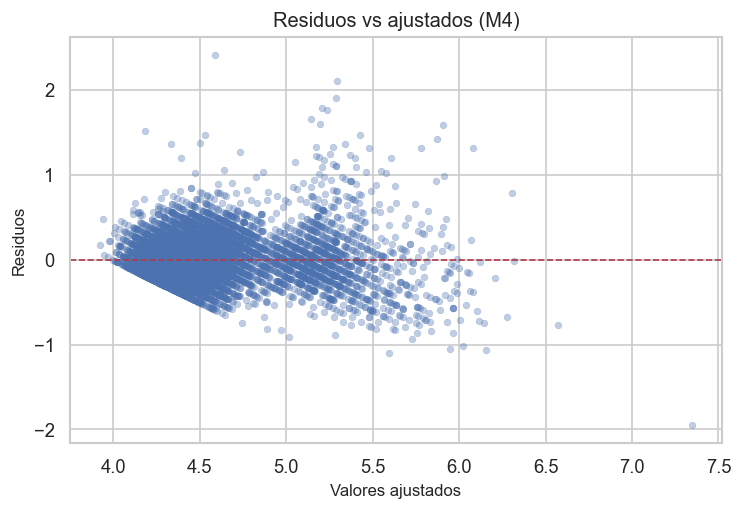

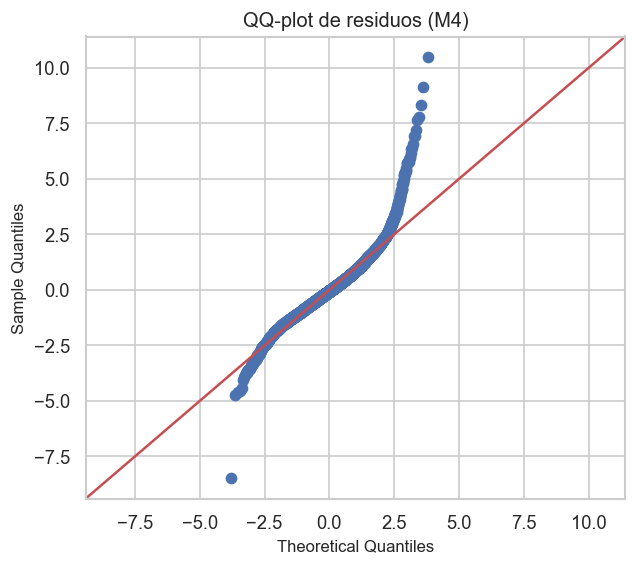

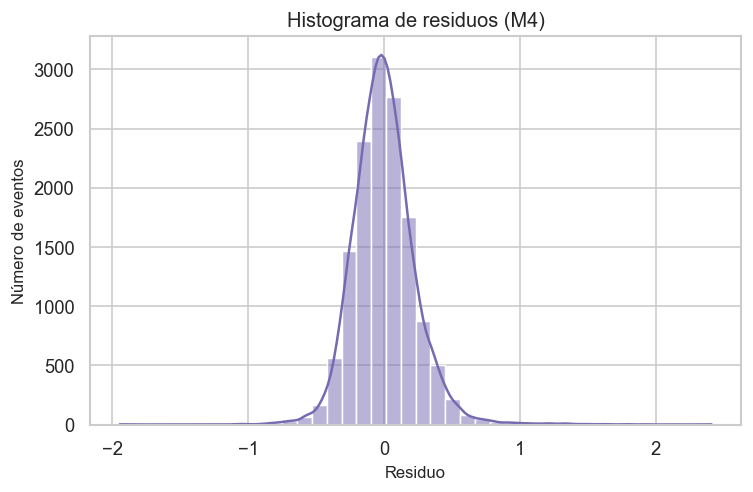

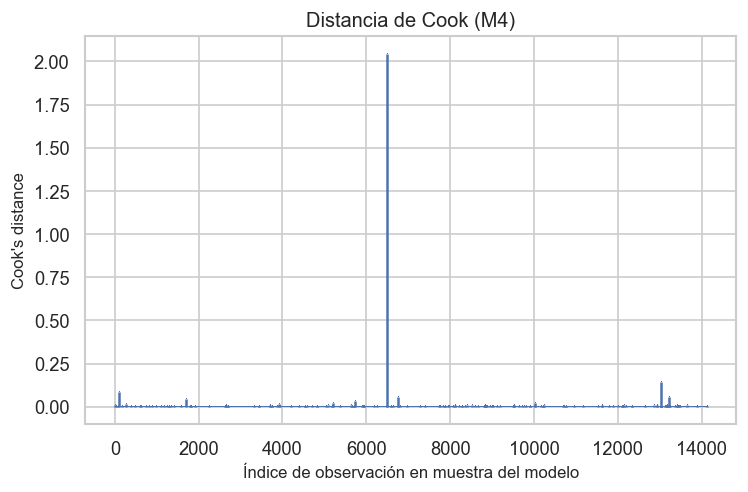

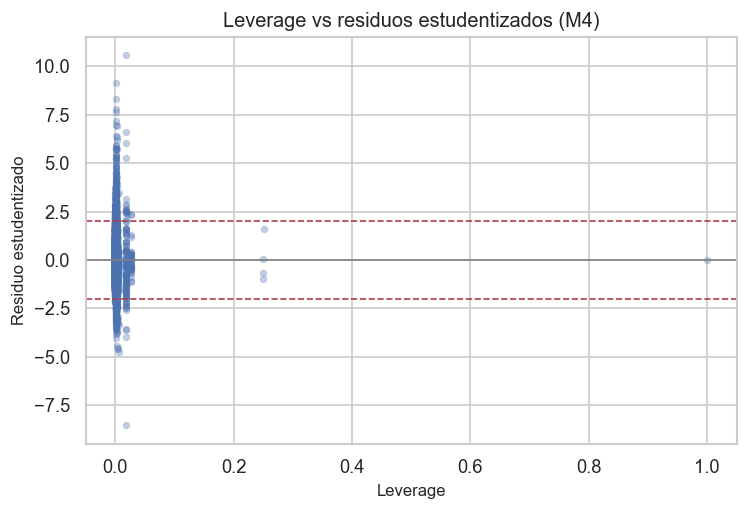

In [12]:
fit = candidate_model
infl = fit.get_influence()
fitted = fit.fittedvalues
resid = fit.resid
studentized = infl.resid_studentized_internal
leverage = infl.hat_matrix_diag
cooks_d = infl.cooks_distance[0]

plt.figure(figsize=(7.0, 4.4))
sns.scatterplot(x=fitted, y=resid, alpha=0.35, s=16, edgecolor=None)
plt.axhline(0, color="#b23a48", linestyle="--", linewidth=1)
plt.title(f"Residuos vs ajustados ({candidate_model_name})")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
save_current_figure("fig_resid_fitted")

plt.figure(figsize=(5.8, 5.0))
sm.qqplot(resid, line="45", fit=True, ax=plt.gca())
plt.title(f"QQ-plot de residuos ({candidate_model_name})")
save_current_figure("fig_qq_resid")

plt.figure(figsize=(7.0, 4.2))
sns.histplot(resid, bins=40, kde=True, color="#756bb1")
plt.title(f"Histograma de residuos ({candidate_model_name})")
plt.xlabel("Residuo")
plt.ylabel("Número de eventos")
save_current_figure("fig_hist_resid")

plt.figure(figsize=(7.0, 4.2))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
plt.title(f"Distancia de Cook ({candidate_model_name})")
plt.xlabel("Índice de observación en muestra del modelo")
plt.ylabel("Cook's distance")
save_current_figure("fig_cooks_distance")

plt.figure(figsize=(7.0, 4.4))
sns.scatterplot(x=leverage, y=studentized, alpha=0.35, s=16, edgecolor=None)
plt.axhline(0, color="gray", linewidth=1)
plt.axhline(2, color="#b23a48", linestyle="--", linewidth=1)
plt.axhline(-2, color="#b23a48", linestyle="--", linewidth=1)
plt.title(f"Leverage vs residuos estudentizados ({candidate_model_name})")
plt.xlabel("Leverage")
plt.ylabel("Residuo estudentizado")
save_current_figure("fig_leverage_resid")


In [13]:
vif_vars = ["log_depth_plus_1", "latitude", "longitude", "nst", "gap", "dmin", "rms"]
vif_vars = [col for col in vif_vars if col in df_model.columns]
vif_data = df_model[vif_vars].dropna().copy()
if {"latitude", "longitude"}.issubset(vif_data.columns) and candidate_model_name == "M6":
    vif_data["latitude_sq"] = vif_data["latitude"] ** 2
    vif_data["longitude_sq"] = vif_data["longitude"] ** 2
    vif_data["lat_lon"] = vif_data["latitude"] * vif_data["longitude"]

if len(vif_vars) >= 2 and len(vif_data) > 0:
    X = sm.add_constant(vif_data, has_constant="add")
    vif_rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        try:
            vif_value = variance_inflation_factor(X.values, i)
        except Exception:
            vif_value = np.nan
        vif_rows.append({"variable": col, "VIF": vif_value})
    vif_table = pd.DataFrame(vif_rows)
    vif_table["VIF"] = vif_table["VIF"].round(3)
else:
    vif_table = pd.DataFrame(columns=["variable", "VIF"])

vif_table.to_csv(REPORT_TABLE_DIR / "vif_table.csv", index=False)
vif_table.to_csv(OUTPUT_TABLE_DIR / "vif_table.csv", index=False)
write_latex_tabular(vif_table, REPORT_TABLE_DIR / "vif_table.tex", column_format="lr")
display(vif_table)


,variable,VIF
0,log_depth_plus_1,1.110
1,latitude,1.360
2,longitude,1.128
3,nst,1.347
4,gap,1.287
5,dmin,1.157
6,rms,1.018


### Interpretación preliminar de diagnósticos

Los residuos vs ajustados permiten revisar si queda estructura sistemática no capturada por el modelo lineal. El QQ-plot y el histograma evalúan normalidad aproximada, relevante para inferencia pero no para la estimación por mínimos cuadrados. La distancia de Cook y el gráfico de leverage ayudan a detectar observaciones con influencia potencial. La tabla VIF informa colinealidad entre predictores numéricos principales. Además, como los datos son eventos puntuales localizados, en el informe final se debe discutir si quedan patrones espaciales en residuos; un modelo CAR no es el enfoque directo salvo que se agreguen eventos por áreas o grillas.


## 11. Consideraciones éticas y uso responsable

Los datos provienen de una fuente oficial y pública, y no contienen datos personales. El riesgo ético directo es bajo. Aun así, el uso responsable exige no presentar este trabajo como predicción operacional de terremotos, sistema de alerta o recomendación de seguridad pública. Las conclusiones se deben formular como asociaciones estadísticas dentro del catálogo USGS 2024 con magnitud al menos 4, reconociendo sus limitaciones de cobertura, codificación y truncamiento.


## 12. Reproducibilidad

El notebook genera la base procesada, las tablas y las figuras usadas por el informe LaTeX. También se guardan archivos con versiones de paquetes y una guía de ejecución.


In [14]:
import importlib.metadata as md

packages = ["pandas", "numpy", "matplotlib", "seaborn", "statsmodels", "scipy", "nbformat", "nbclient"]
version_rows = []
for package in packages:
    try:
        version_rows.append((package, md.version(package)))
    except md.PackageNotFoundError:
        version_rows.append((package, "No instalado"))

session_lines = [
    f"Python: {sys.version.split()[0]}",
    f"Ruta relativa de datos: {RAW_DATA_PATH.relative_to(PROJECT_DIR)}",
    "Figuras del informe: Avance/Plantilla_informe/figures/",
    "Tablas del informe: Avance/Plantilla_informe/tables/",
    "",
    "Paquetes principales:",
]
session_lines += [f"{package}: {version}" for package, version in version_rows]
(ADVANCE_DIR / "session_info.txt").write_text("\n".join(session_lines) + "\n", encoding="utf-8")

requirements_text = "\n".join(
    f"{package}=={version}" for package, version in version_rows if version != "No instalado"
) + "\n"
(ADVANCE_DIR / "requirements.txt").write_text(requirements_text, encoding="utf-8")

readme_text = """# Avance Proyecto de Regresión: USGS Earthquakes 2024

Este avance analiza, con enfoque descriptivo-explicativo, cómo se asocia la magnitud reportada (`mag`) de eventos sísmicos USGS durante 2024 con profundidad, localización geográfica y características técnicas del registro.

## Fuente de datos

- Fuente: U.S. Geological Survey, Earthquake Catalog API.
- Periodo: eventos registrados durante 2024.
- Filtro de muestra: magnitud al menos 4.
- Unidad de observación: evento sísmico.
- Archivo crudo: `usgs_earthquakes_2024_mag4_raw.csv`.

## Cómo ejecutar

1. Abrir `avance_proyecto_regresion.ipynb` desde la carpeta `Avance/` o desde la raíz del proyecto.
2. Ejecutar todas las celdas en orden.
3. El notebook genera la base `usgs_earthquakes_2024_mag4_model_ready.csv`, las figuras y las tablas del informe.

## Estructura

- `avance_proyecto_regresion.ipynb`: limpieza, EDA, modelos preliminares y diagnósticos.
- `usgs_earthquakes_2024_mag4_raw.csv`: datos crudos.
- `usgs_earthquakes_2024_mag4_model_ready.csv`: base procesada generada por el notebook.
- `outputs/figures/` y `outputs/tables/`: copias de trabajo.
- `Plantilla_informe/main.tex`: avance en LaTeX.
- `Plantilla_informe/figures/`: figuras leídas por LaTeX.
- `Plantilla_informe/tables/`: tablas leídas por LaTeX.

## Compilación del informe

Compilar `Plantilla_informe/main.tex` con XeLaTeX desde la carpeta `Avance/Plantilla_informe/`:

```bash
latexmk -C
latexmk -xelatex -interaction=nonstopmode -file-line-error main.tex
```

Las figuras y tablas se generan desde el notebook y se cargan con rutas relativas.

## Repositorio

https://github.com/Paul0112/proyecto_regresion

## Nota metodológica

El análisis no busca predecir terremotos futuros ni emitir alertas. Las conclusiones se interpretan como asociaciones estadísticas dentro de la muestra truncada a magnitud >= 4.
"""
(ADVANCE_DIR / "README.md").write_text(readme_text, encoding="utf-8")

session_df = pd.DataFrame(version_rows, columns=["paquete", "versión"])
display(session_df)
print(f"Archivos reproducibles guardados en {ADVANCE_DIR.relative_to(PROJECT_DIR)}: requirements.txt, session_info.txt y README.md")


,paquete,versión
0,pandas,2.2.3
1,numpy,2.2.1
2,matplotlib,3.10.0
3,seaborn,0.13.2
4,statsmodels,0.14.4
5,scipy,1.15.1
6,nbformat,5.10.4
7,nbclient,0.10.2


Archivos reproducibles guardados en Avance: requirements.txt, session_info.txt y README.md
